# Đánh giá Local — Test trọng số đã train (Classifier + U-Net)

Notebook này **không cần backend/API** — load thẳng `weights/best_classifier.pth` và
`weights/best_unet.pth`, chạy trên CPU máy local để:

1. Test nhanh 1 ảnh: dự đoán + xác suất + Grad-CAM heatmap + mask phổi từ U-Net.
2. Đánh giá đầy đủ trên **TEST SET** cho classifier (Precision/Recall/F1 từng lớp, Confusion Matrix)
   — theo đúng `docs/TUTORIAL.md` Phần 17.2. Lưu ý: đây là **test set**, không phải val — val đã
   dùng để chọn checkpoint lúc train, chỉ chạy test set **một lần** khi đã chốt model.
3. Đánh giá đầy đủ trên TEST SET cho U-Net (Dice/IoU) + 3 case tốt nhất/tệ nhất — Phần 17.3.

**Trước khi chạy:** copy 2 file `best_classifier.pth` và `best_unet.pth` đã tải từ Colab vào
thư mục `weights/` ở gốc repo.


In [1]:
import os
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    """Tim thu muc goc repo (chua src/) bang cach di nguoc len tu thu muc hien tai —
    can thiet vi kernel Jupyter co the khoi dong o notebooks/ thay vi goc repo."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(
        "Khong tim thay thu muc src/ tu day - hay mo notebook nay tu trong repo "
        "Chest-X-ray-Segmentation-and-Diagnosis-of-Pneumonia-and-COVID-19."
    )

REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Working directory:", Path.cwd())


Working directory: d:\PYML-Project\Chest-X-ray-Segmentation-and-Diagnosis-of-Pneumonia-and-COVID-19


In [2]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.dataset import (
    ChestXrayClassificationDataset, ChestXraySegmentationDataset,
    get_val_transforms, get_val_transforms_seg,
    IDX_TO_CLASS, NUM_CLASSES,
)
from src.model import load_classifier
from src.unet import build_unet, dice_score, iou_score
from src.gradcam import generate_gradcam, overlay_heatmap

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

CLF_PATH = Path("weights/best_classifier.pth")
UNET_PATH = Path("weights/best_unet.pth")

for p in (CLF_PATH, UNET_PATH):
    if not p.exists():
        raise FileNotFoundError(
            f"Khong tim thay {p} - hay copy file .pth da tai tu Colab vao thu muc "
            "weights/ truoc khi chay tiep."
        )
print("OK: tim thay ca 2 checkpoint.")


c:\Users\PHUC THINH\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cpu
OK: tim thay ca 2 checkpoint.


In [3]:
classifier = load_classifier(str(CLF_PATH), num_classes=NUM_CLASSES, device=DEVICE, verbose=True)

unet = build_unet(pretrained=False, verbose=False)
unet.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE))
unet.to(DEVICE).eval()
print("OK: da load classifier + U-Net, ca hai o eval mode.")


[model] load_classifier   | path='weights\\best_classifier.pth' device=cpu eval=True
OK: da load classifier + U-Net, ca hai o eval mode.


## 1. Test nhanh trên 1 ảnh — dự đoán + Grad-CAM + mask phổi

Đổi `idx` ở cell dưới để thử ảnh khác trong test set.

📊 Dataset loaded: 1350 images from data/split/test
Ảnh: COVID-1000.png
Nhãn thật: COVID
Dự đoán:   COVID (100.0%)
  Normal         :   0.0%
  Lung_Opacity   :   0.0%
  COVID          : 100.0%


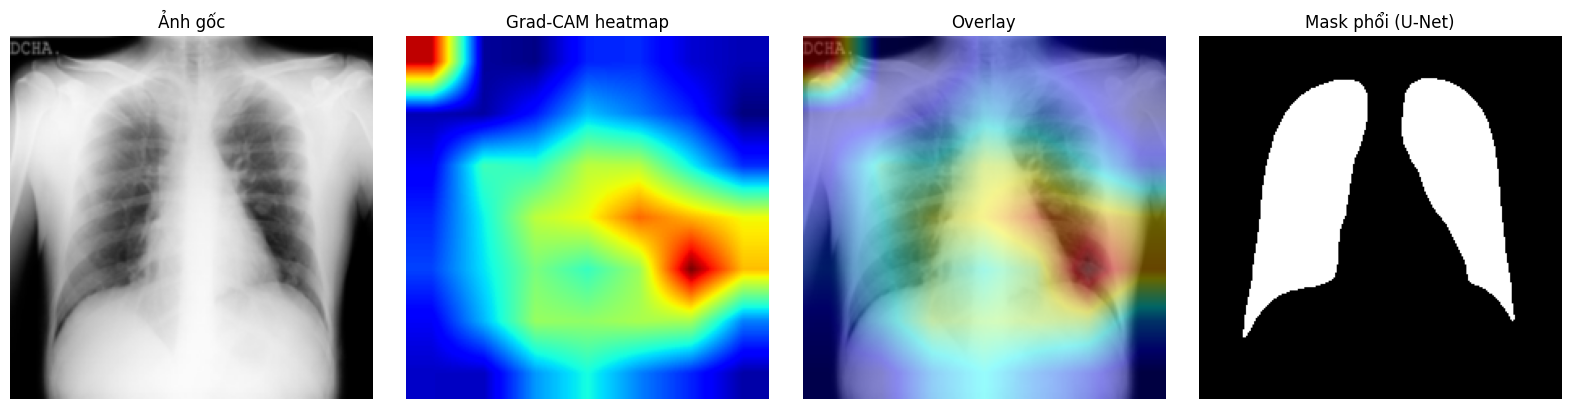

In [4]:
test_ds = ChestXrayClassificationDataset("data/split/test", get_val_transforms())

idx = 0  # đổi số này để thử ảnh khác trong test set (0 .. len(test_ds)-1)
img_tensor, label = test_ds[idx]
image_path = test_ds.image_paths[idx]

with torch.no_grad():
    logits = classifier(img_tensor.unsqueeze(0).to(DEVICE))
    probs = logits.softmax(dim=1)[0].cpu().numpy()

pred_idx = int(probs.argmax())
print(f"Ảnh: {image_path.name}")
print(f"Nhãn thật: {IDX_TO_CLASS[label]}")
print(f"Dự đoán:   {IDX_TO_CLASS[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
for i, p in enumerate(probs):
    print(f"  {IDX_TO_CLASS[i]:15s}: {p*100:5.1f}%")

# Grad-CAM — CẦN gradient, generate_gradcam() tự lo việc này, không cần no_grad() ở đây
heatmap = generate_gradcam(classifier, img_tensor, target_class=pred_idx)

# Mask phổi từ U-Net, dùng chính img_tensor đã chuẩn hoá (cùng input với classifier)
with torch.no_grad():
    unet_logits = unet(img_tensor.unsqueeze(0).to(DEVICE))
    lung_mask = (torch.sigmoid(unet_logits)[0, 0] > 0.5).cpu().numpy()

# Đọc lại ảnh gốc từ đĩa để overlay (224x224, RGB) — KHÔNG dùng img_tensor đã normalize
orig = np.array(Image.open(image_path).convert("RGB").resize((224, 224)))
overlay = overlay_heatmap(orig, heatmap)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(orig); axes[0].set_title("Ảnh gốc"); axes[0].axis("off")
axes[1].imshow(heatmap, cmap="jet"); axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
axes[3].imshow(lung_mask, cmap="gray"); axes[3].set_title("Mask phổi (U-Net)"); axes[3].axis("off")
plt.tight_layout()
plt.show()


## 2. Đánh giá đầy đủ trên TEST SET — Classifier

(`docs/TUTORIAL.md` Phần 17.2 — Precision/Recall/F1 từng lớp + Confusion Matrix)

Evaluating classifier on test set: 100%|██████████| 43/43 [02:40<00:00,  3.73s/it]


              precision    recall  f1-score   support

      Normal     0.8793    0.9556    0.9159       450
Lung_Opacity     0.9738    0.8267    0.8942       450
       COVID     0.9332    0.9933    0.9623       450

    accuracy                         0.9252      1350
   macro avg     0.9288    0.9252    0.9241      1350
weighted avg     0.9288    0.9252    0.9241      1350



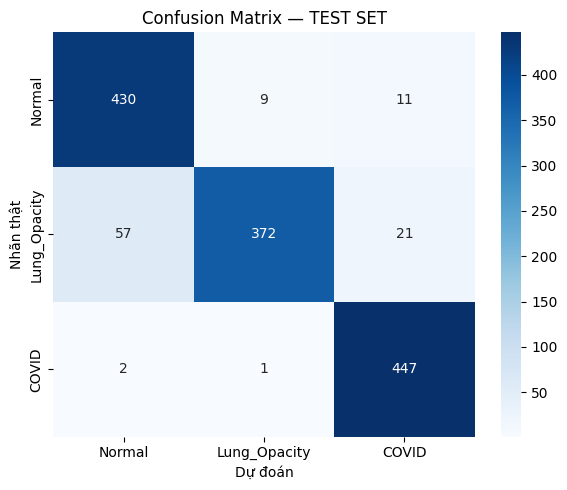

In [5]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Evaluating classifier on test set"):
        probs = classifier(x.to(DEVICE)).softmax(dim=1).cpu()
        y_true.extend(y.tolist())
        y_pred.extend(probs.argmax(1).tolist())

class_names = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Dự đoán"); plt.ylabel("Nhãn thật")
plt.title("Confusion Matrix — TEST SET")
plt.tight_layout()
plt.show()


## 3. Đánh giá đầy đủ trên TEST SET — U-Net

(`docs/TUTORIAL.md` Phần 17.3 — Dice/IoU trung bình + 3 case tốt nhất/tệ nhất để kiểm tra định tính)

In [6]:
test_seg_ds = ChestXraySegmentationDataset("data/split/test", get_val_transforms_seg())
test_seg_loader = DataLoader(test_seg_ds, batch_size=16, shuffle=False)

dices, ious = [], []
with torch.no_grad():
    for x, y in tqdm(test_seg_loader, desc="Evaluating U-Net on test set"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = unet(x)
        dices.append(dice_score(logits, y))
        ious.append(iou_score(logits, y))

print(f"Test Dice: {np.mean(dices):.4f} +/- {np.std(dices):.4f}")
print(f"Test IoU : {np.mean(ious):.4f} +/- {np.std(ious):.4f}")


📊 Segmentation dataset loaded: 1350 images from data/split/test


Evaluating U-Net on test set: 100%|██████████| 85/85 [02:22<00:00,  1.68s/it]

Test Dice: 0.9879 +/- 0.0040
Test IoU : 0.9761 +/- 0.0078


Per-image Dice: 100%|██████████| 1350/1350 [03:34<00:00,  6.28it/s]


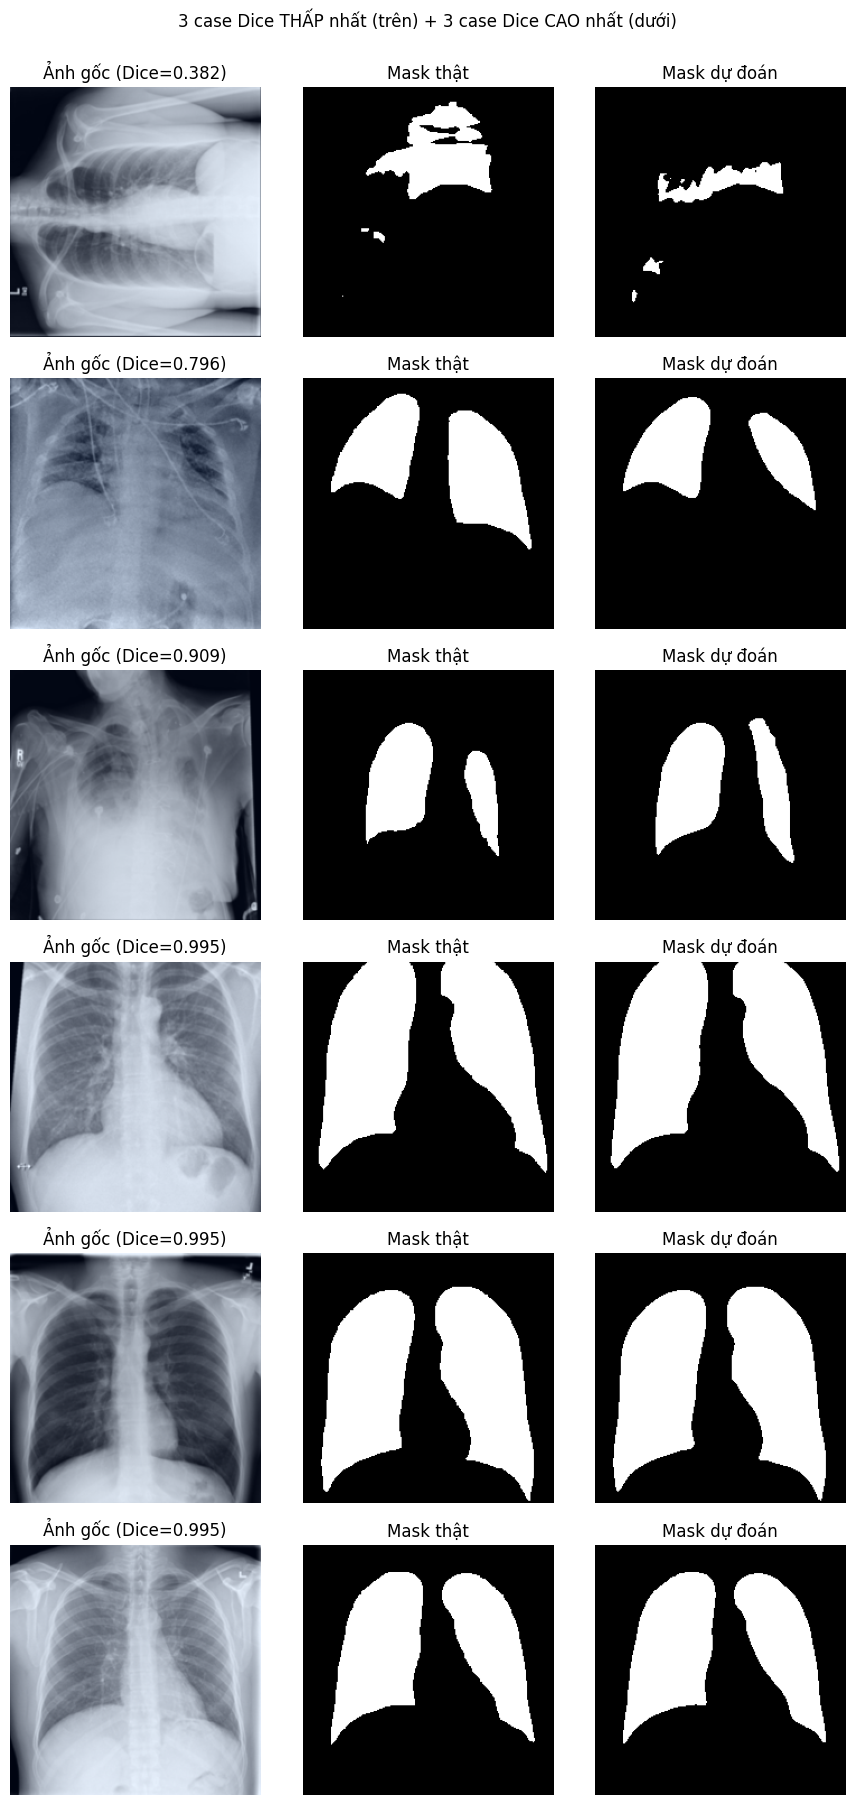

In [7]:
# Tính Dice riêng từng ảnh để tìm case tốt nhất/tệ nhất (chạy chậm hơn vì lặp từng ảnh,
# nhưng test set chỉ ~1350 ảnh nên vẫn đủ nhanh trên CPU)
per_image_dice = []
with torch.no_grad():
    for i in tqdm(range(len(test_seg_ds)), desc="Per-image Dice"):
        img, mask = test_seg_ds[i]
        logits = unet(img.unsqueeze(0).to(DEVICE))
        d = dice_score(logits, mask.unsqueeze(0).to(DEVICE))
        per_image_dice.append(d)

order = np.argsort(per_image_dice)
worst_idx = order[:3]
best_idx = order[-3:]

def show_case(ax_row, idx):
    img, mask = test_seg_ds[idx]
    with torch.no_grad():
        logits = unet(img.unsqueeze(0).to(DEVICE))
        pred = (torch.sigmoid(logits)[0, 0] > 0.5).cpu().numpy()
    img_show = img.permute(1, 2, 0).numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)
    ax_row[0].imshow(img_show); ax_row[0].set_title(f"Ảnh gốc (Dice={per_image_dice[idx]:.3f})"); ax_row[0].axis("off")
    ax_row[1].imshow(mask[0].numpy(), cmap="gray"); ax_row[1].set_title("Mask thật"); ax_row[1].axis("off")
    ax_row[2].imshow(pred, cmap="gray"); ax_row[2].set_title("Mask dự đoán"); ax_row[2].axis("off")

fig, axes = plt.subplots(6, 3, figsize=(9, 18))
for row, idx in enumerate(list(worst_idx) + list(best_idx)):
    show_case(axes[row], idx)
fig.suptitle("3 case Dice THẤP nhất (trên) + 3 case Dice CAO nhất (dưới)", y=1.0)
plt.tight_layout()
plt.show()


## 4. Kiểm định Shortcut Learning — xem nhanh case IoU thấp nhất (tập con)

So khớp Grad-CAM heatmap với mask phổi thật bằng IoU (`docs/LY_THUYET.md` Phần VIII).
Chạy trên **tập con 150 ảnh** để xem nhanh trong vài phút — con số thống kê đầy đủ
(1350 ảnh × 2 nguồn mask) chạy riêng qua `python -m src.shortcut_iou` (mất ~40 phút,
lưu kết quả vào `figures/shortcut_iou_*.png`).


In [8]:
import random
from src.shortcut_iou import binarize, iou, load_gt_mask

N_SUBSET = 150
GRADCAM_THRESH = 0.5
random.seed(42)

ds_shortcut = ChestXrayClassificationDataset("data/split/test", get_val_transforms())
mask_dir = Path("data/split/test/masks")
subset_idx = random.sample(range(len(ds_shortcut)), N_SUBSET)

records = []
for i in tqdm(subset_idx, desc="Quick shortcut check (subset)"):
    img, label = ds_shortcut[i]
    path = ds_shortcut.image_paths[i]
    heatmap = generate_gradcam(classifier, img, target_class=label)
    cam_bin = binarize(heatmap, GRADCAM_THRESH)
    lung_mask = load_gt_mask(path, mask_dir)
    score = iou(cam_bin, lung_mask)
    records.append({"idx": i, "path": path, "label": label, "class": IDX_TO_CLASS[label], "iou": score})

records.sort(key=lambda r: r["iou"])
mean_iou = np.mean([r["iou"] for r in records])
print(f"Mean IoU (subset {N_SUBSET} ảnh, ngưỡng {GRADCAM_THRESH}): {mean_iou:.3f}")
print("5 case IoU thấp nhất:")
for r in records[:5]:
    print(f"  {r['path'].name:20s} lớp={r['class']:15s} IoU={r['iou']:.3f}")


📊 Dataset loaded: 1350 images from data/split/test


Quick shortcut check (subset): 100%|██████████| 150/150 [01:14<00:00,  2.01it/s]

Mean IoU (subset 150 ảnh, ngưỡng 0.5): 0.161
5 case IoU thấp nhất:
  COVID-2176.png       lớp=COVID           IoU=0.000
  COVID-1557.png       lớp=COVID           IoU=0.000
  Lung_Opacity-4644.png lớp=Lung_Opacity    IoU=0.000
  COVID-1583.png       lớp=COVID           IoU=0.000
  COVID-3507.png       lớp=COVID           IoU=0.000


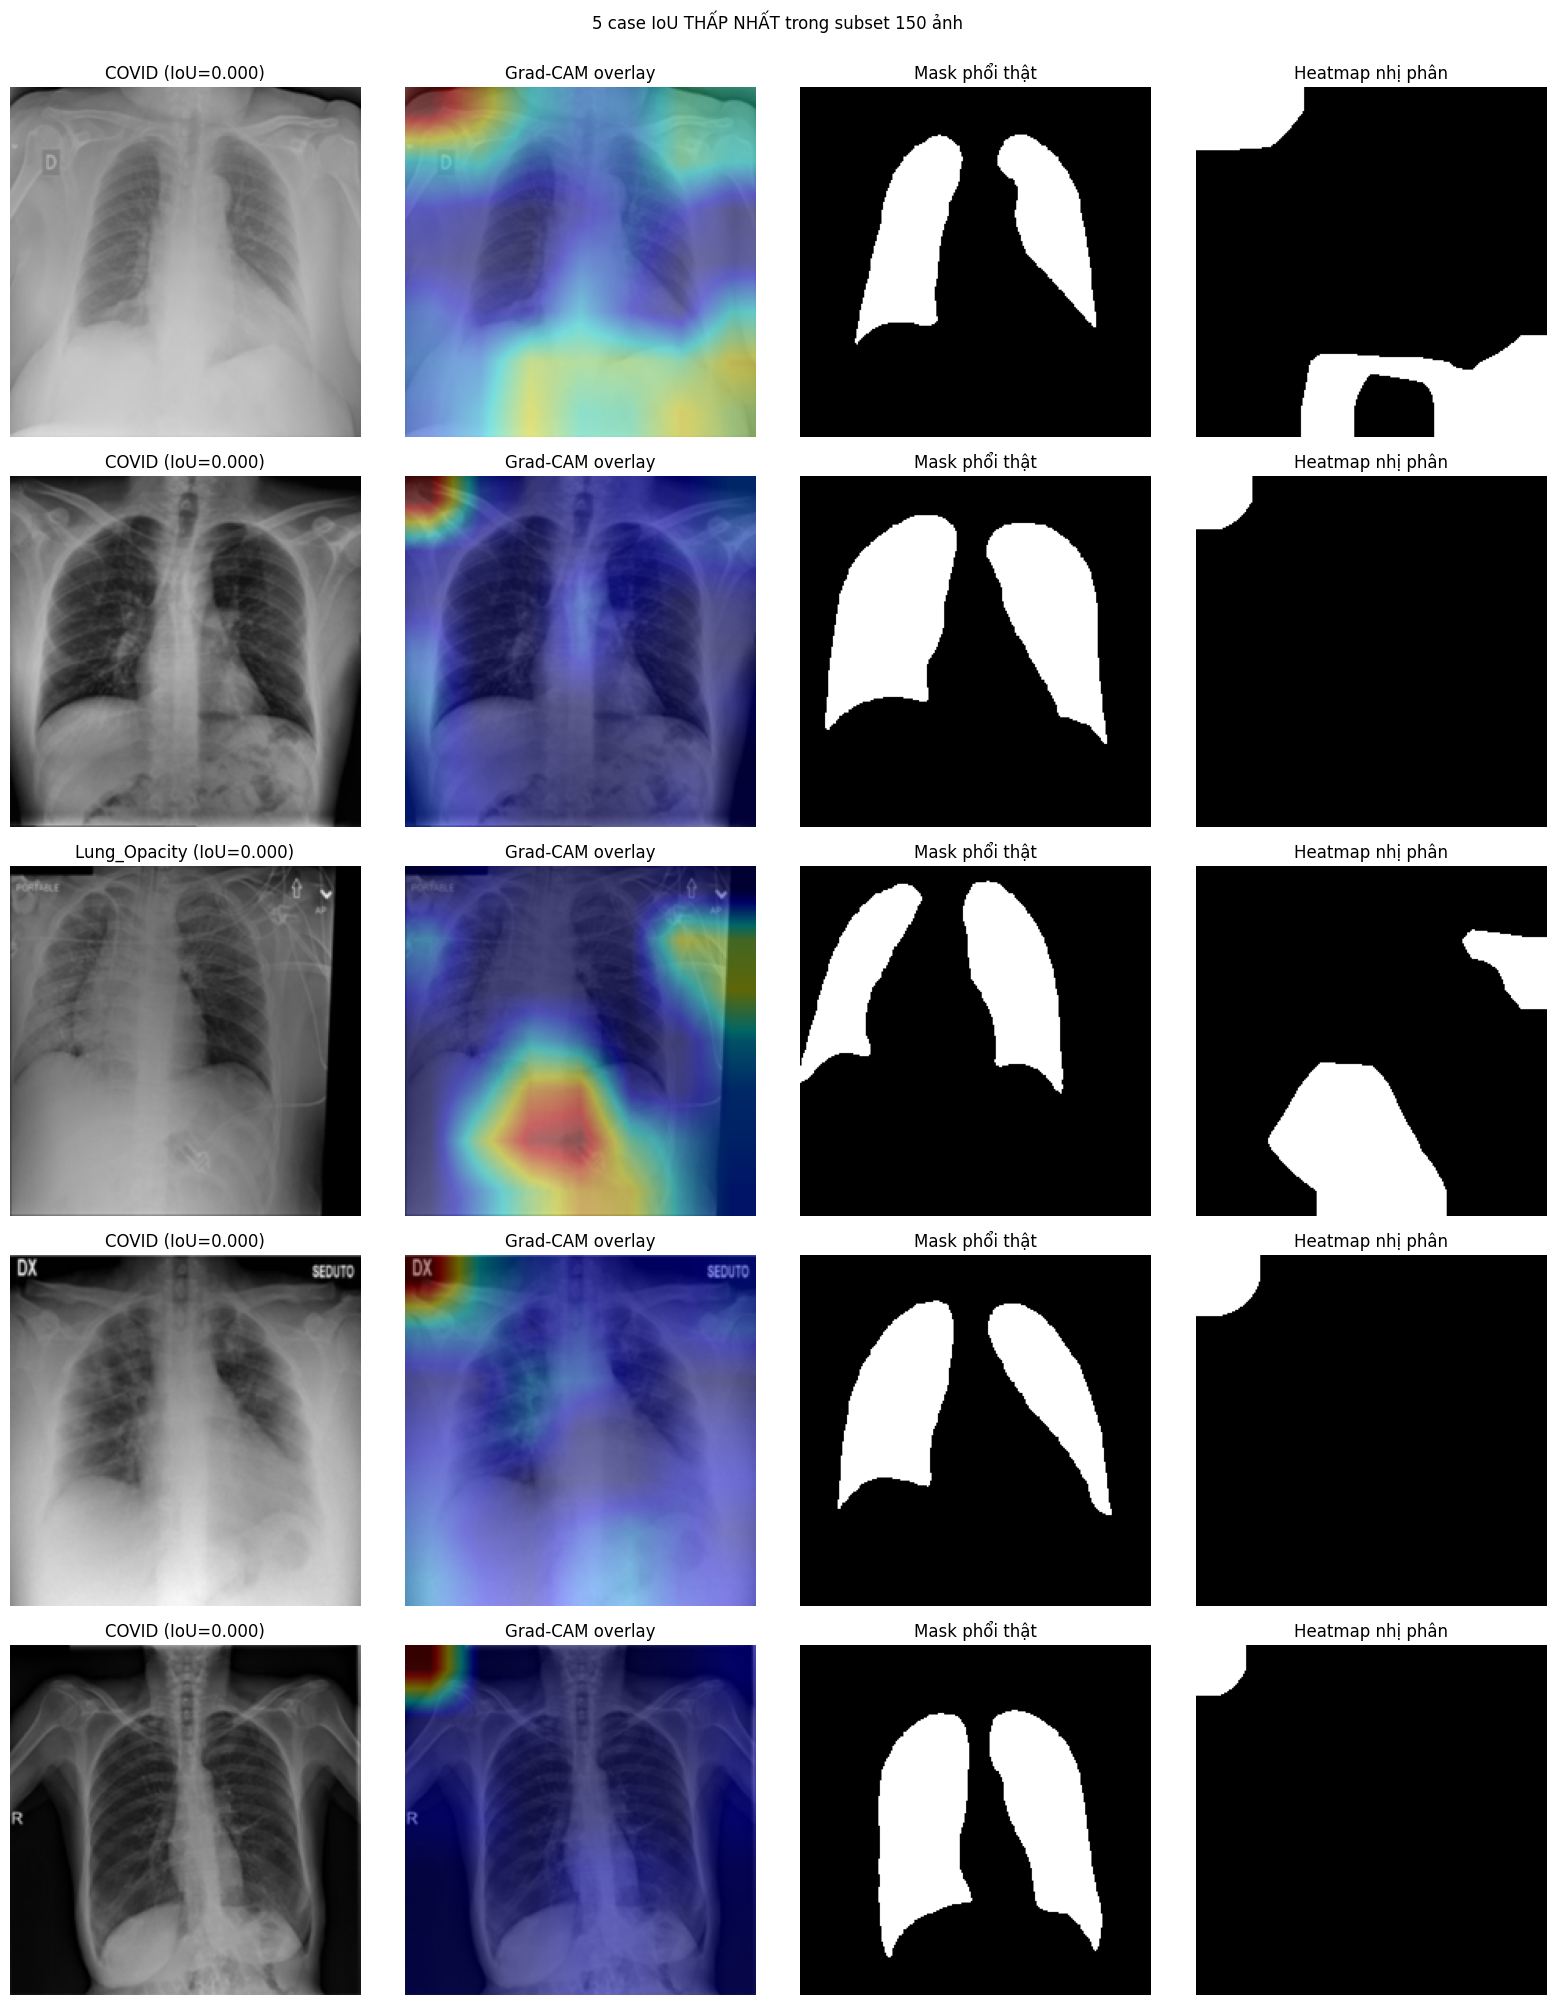

In [9]:
n_show = 5
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))

for row, rec in enumerate(records[:n_show]):
    img_tensor, _ = ds_shortcut[rec["idx"]]
    heatmap = generate_gradcam(classifier, img_tensor, target_class=rec["label"])
    lung_mask = load_gt_mask(rec["path"], mask_dir)

    orig = np.array(Image.open(rec["path"]).convert("RGB").resize((224, 224)))
    overlay = overlay_heatmap(orig, heatmap)

    axes[row, 0].imshow(orig); axes[row, 0].set_title(f"{rec['class']} (IoU={rec['iou']:.3f})"); axes[row, 0].axis("off")
    axes[row, 1].imshow(overlay); axes[row, 1].set_title("Grad-CAM overlay"); axes[row, 1].axis("off")
    axes[row, 2].imshow(lung_mask, cmap="gray"); axes[row, 2].set_title("Mask phổi thật"); axes[row, 2].axis("off")
    axes[row, 3].imshow(binarize(heatmap, GRADCAM_THRESH), cmap="gray"); axes[row, 3].set_title("Heatmap nhị phân"); axes[row, 3].axis("off")

fig.suptitle(f"{n_show} case IoU THẤP NHẤT trong subset {N_SUBSET} ảnh", y=1.0)
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/shortcut_worst_cases_subset.png", dpi=120, bbox_inches="tight")
plt.show()
